In [50]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder, OrdinalEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

from sklearn.linear_model import LinearRegression, Ridge, LogisticRegression

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    confusion_matrix,
    classification_report,
    ConfusionMatrixDisplay
)

#Ingreso de datos

In [51]:
import kagglehub
import pandas as pd
import os

# Descargar el dataset usando kagglehub
path = kagglehub.dataset_download("prachi13/customer-analytics")

print(f"Ruta a los archivos del dataset: {path}")

# Listar los archivos en el directorio descargado para encontrar el CSV
csv_files = [f for f in os.listdir(path) if f.endswith('.csv')]

if csv_files:
    file_name = csv_files[0]
    full_file_path = os.path.join(path, file_name)

    df = pd.read_csv(full_file_path)
    print(f"Dataset '{file_name}' cargado exitosamente. Mostrando las primeras 5 filas:")
    display(df.head())
else:
    print(f"Error: No se encontraron archivos .csv en el directorio: {path}. Por favor, verifica el contenido del dataset descargado.")

Using Colab cache for faster access to the 'customer-analytics' dataset.
Ruta a los archivos del dataset: /kaggle/input/customer-analytics
Dataset 'Train.csv' cargado exitosamente. Mostrando las primeras 5 filas:


,ID,Warehouse_block,Mode_of_Shipment,Customer_care_calls,Customer_rating,Cost_of_the_Product,Prior_purchases,Product_importance,Gender,Discount_offered,Weight_in_gms,Reached.on.Time_Y.N
0,1,D,Flight,4,2,177,3,low,F,44,1233,1
1,2,F,Flight,4,5,216,2,low,M,59,3088,1
2,3,A,Flight,2,2,183,4,low,M,48,3374,1
3,4,B,Flight,3,3,176,4,medium,M,10,1177,1
4,5,C,Flight,2,2,184,3,medium,F,46,2484,1


#DATA UNDERSTANDING

##EDA
Analisis exploratorio de datos

In [52]:
df.info();

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10999 entries, 0 to 10998
Data columns (total 12 columns):
 #   Column               Non-Null Count  Dtype 
---  ------               --------------  ----- 
 0   ID                   10999 non-null  int64 
 1   Warehouse_block      10999 non-null  object
 2   Mode_of_Shipment     10999 non-null  object
 3   Customer_care_calls  10999 non-null  int64 
 4   Customer_rating      10999 non-null  int64 
 5   Cost_of_the_Product  10999 non-null  int64 
 6   Prior_purchases      10999 non-null  int64 
 7   Product_importance   10999 non-null  object
 8   Gender               10999 non-null  object
 9   Discount_offered     10999 non-null  int64 
 10  Weight_in_gms        10999 non-null  int64 
 11  Reached.on.Time_Y.N  10999 non-null  int64 
dtypes: int64(8), object(4)
memory usage: 1.0+ MB


### Analisis de algunas variables

Verificamos que el target es el REACHED.ON.TIME Osea el alcanzado a tiempo Ya que definimos que al cliente le llego a tiempo sus pedidos

In [53]:
target_regression = "Cost_of_the_Product"

df[target_regression].value_counts()

,count
Cost_of_the_Product,
245,110
257,109
260,106
254,101
264,100
...,...
96,5
120,5
99,5


In [54]:
target_clasificacion= "Reached.on.Time_Y.N"
df[target_clasificacion].value_counts()


,count
Reached.on.Time_Y.N,
1,6563
0,4436


In [55]:
df["Product_importance"].value_counts()

,count
Product_importance,
low,5297
medium,4754
high,948


In [56]:
df["Mode_of_Shipment"].value_counts()

,count
Mode_of_Shipment,
Ship,7462
Flight,1777
Road,1760


In [57]:
df["Warehouse_block"].value_counts()

,count
Warehouse_block,
F,3666
D,1834
A,1833
B,1833
C,1833


In [58]:
print(f"Máximo costo del producto: {df['Cost_of_the_Product'].max()}")
print(f"Mínimo costo del producto: {df['Cost_of_the_Product'].min()}")

Máximo costo del producto: 310
Mínimo costo del producto: 96


### Correlacion entre variables

In [59]:
numeric_cols = df.select_dtypes(include=np.number).columns
categorical_cols = df.select_dtypes(include='object').columns

print("Numerical Columns:", list(numeric_cols))
print("Categorical Columns:", list(categorical_cols))

Numerical Columns: ['ID', 'Customer_care_calls', 'Customer_rating', 'Cost_of_the_Product', 'Prior_purchases', 'Discount_offered', 'Weight_in_gms', 'Reached.on.Time_Y.N']
Categorical Columns: ['Warehouse_block', 'Mode_of_Shipment', 'Product_importance', 'Gender']


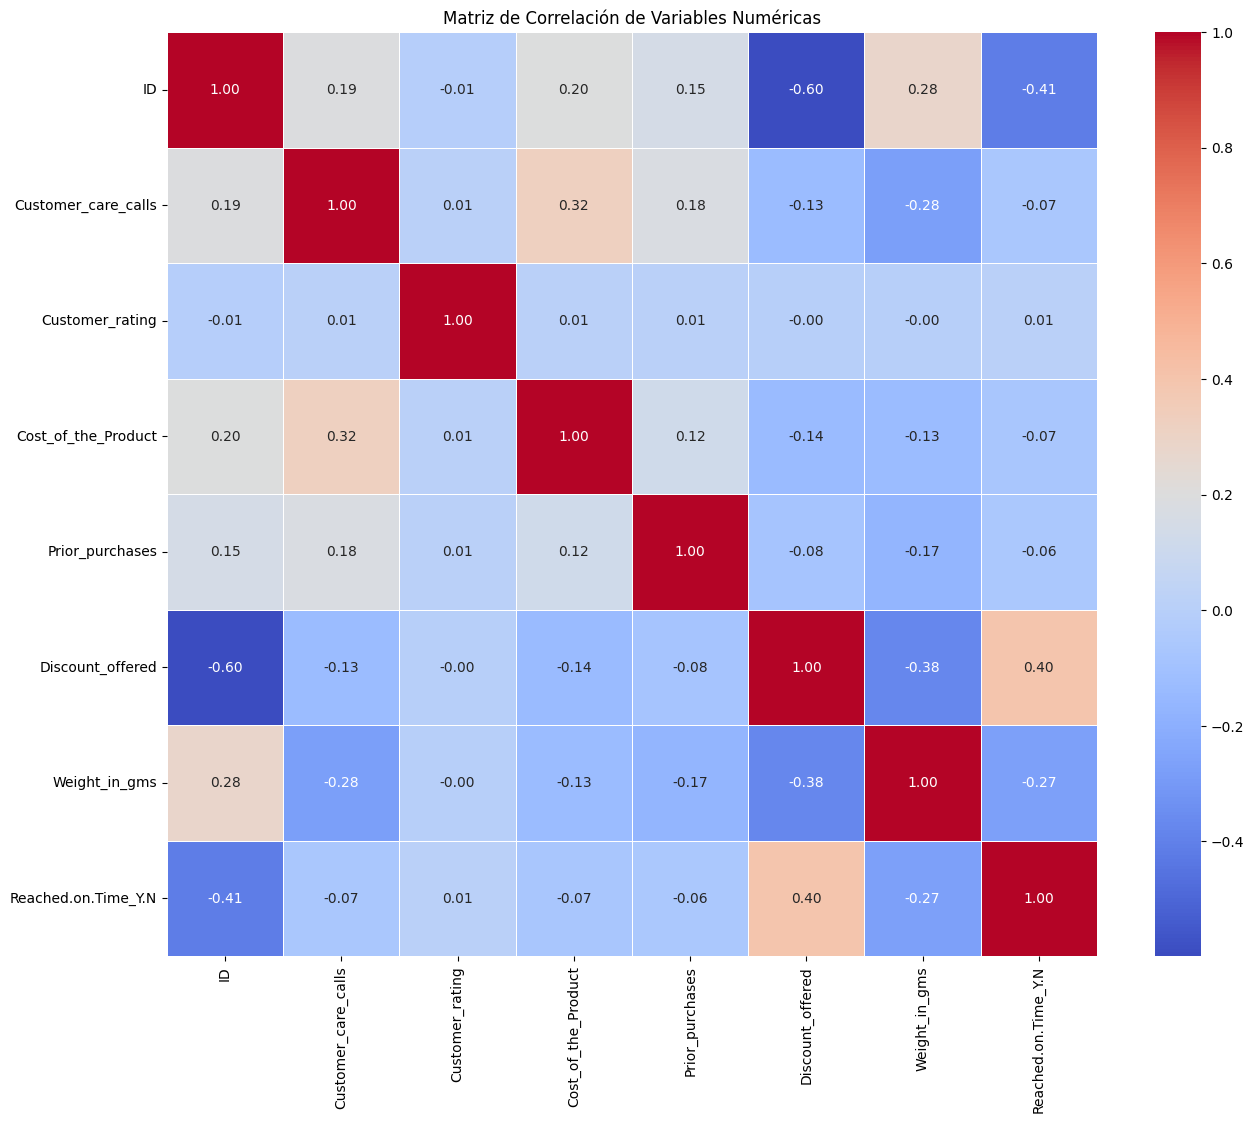

In [60]:
plt.figure(figsize=(15, 12))
sns.heatmap(df[numeric_cols].corr(), annot=True, cmap='coolwarm', fmt='.2f', linewidths=.5)
plt.title('Matriz de Correlación de Variables Numéricas')
plt.show()

### Distribucion de variables
El propósito de esta gráfica es mostrar cómo se distribuyen los valores de las variables numéricas en el conjunto de datos. Esto permite observar patrones, identificar posibles valores atípicos y entender el comportamiento general de los datos antes de aplicar modelos de análisis o aprendizaje automático.

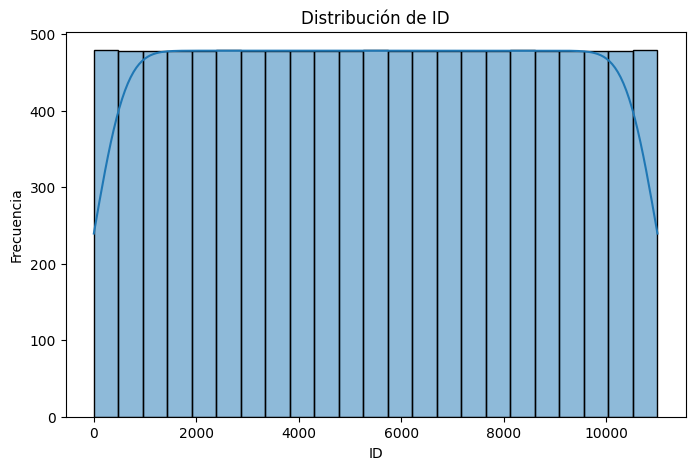

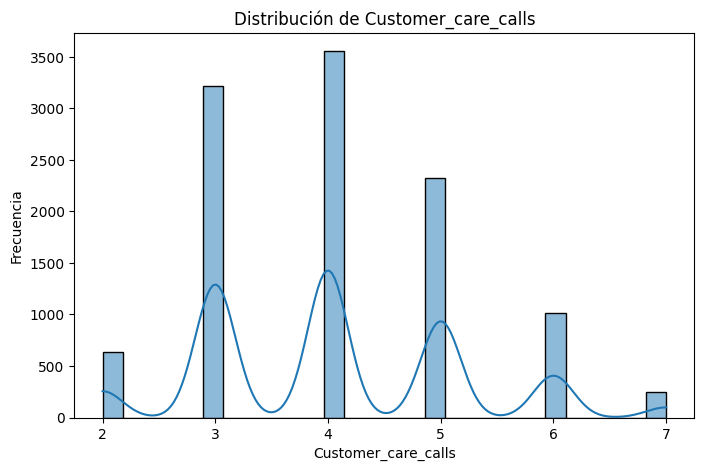

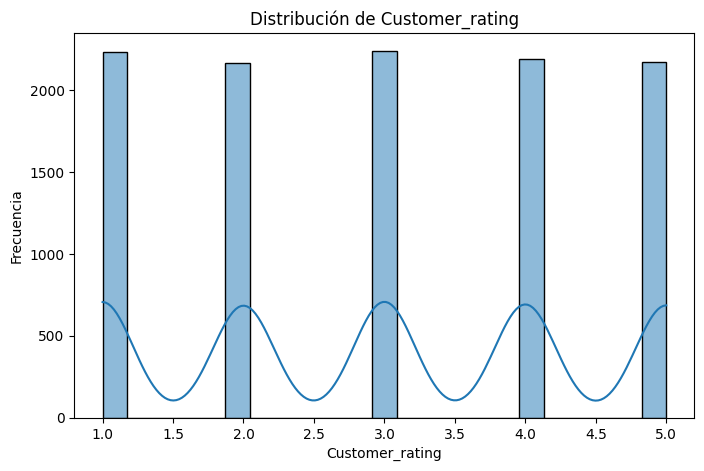

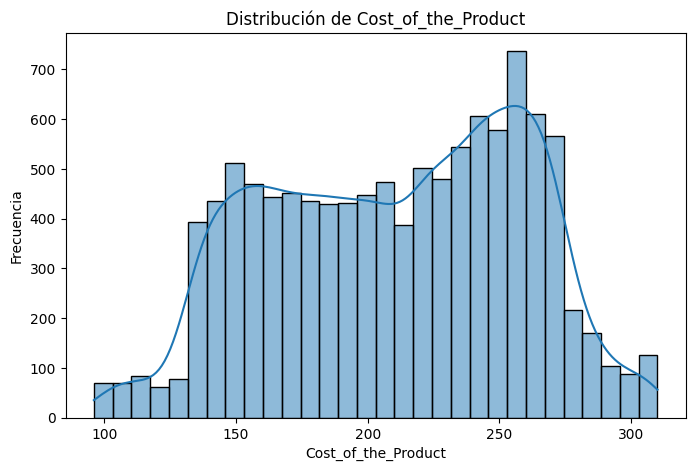

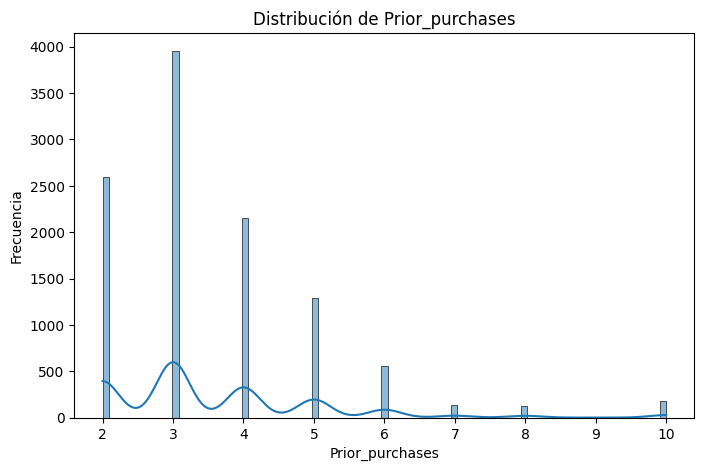

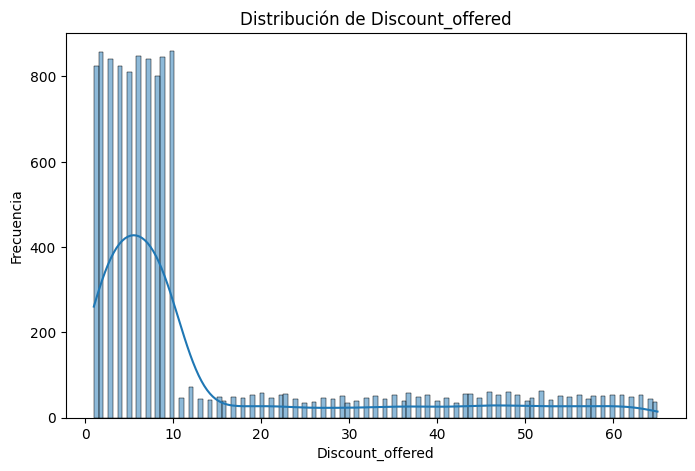

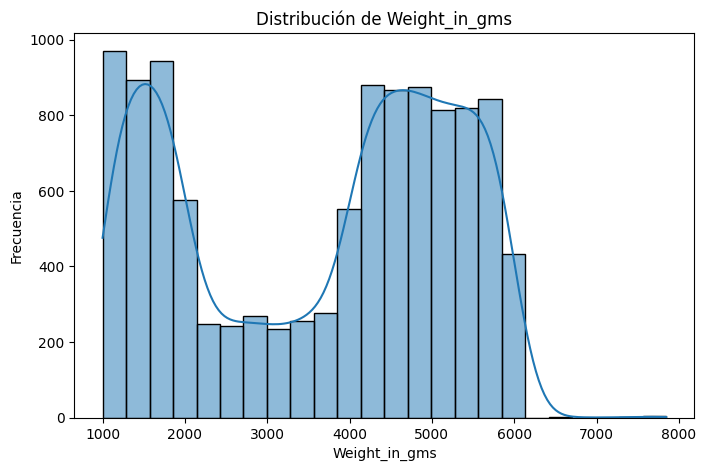

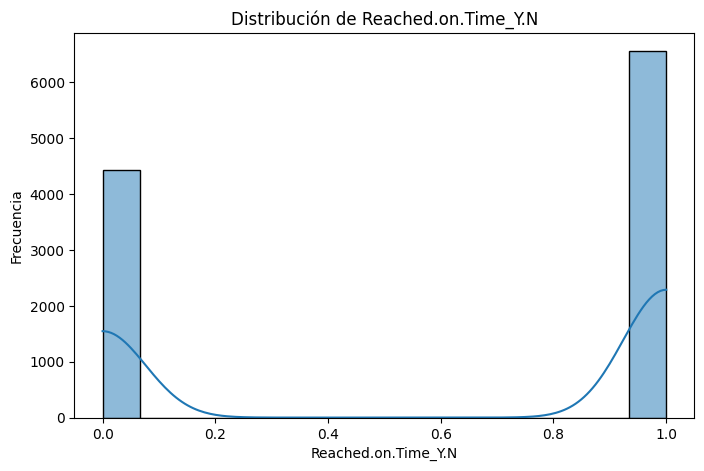

In [61]:
for col in df[numeric_cols].columns:
    plt.figure(figsize=(8, 5))
    sns.histplot(df[col], kde=True)
    plt.title(f'Distribución de {col}')
    plt.xlabel(col)
    plt.ylabel('Frecuencia')
    plt.show()

### Análisis de Dispersión y Detección de Valores Atípicos
El propósito de esta gráfica es identificar la dispersión de los datos y detectar posibles valores atípicos en las variables numéricas del conjunto de datos. El boxplot permite observar la mediana, los rangos de los datos y los valores extremos, lo que ayuda a comprender la variabilidad de cada variable y a detectar datos que podrían afectar el análisis o los modelos de aprendizaje automático.

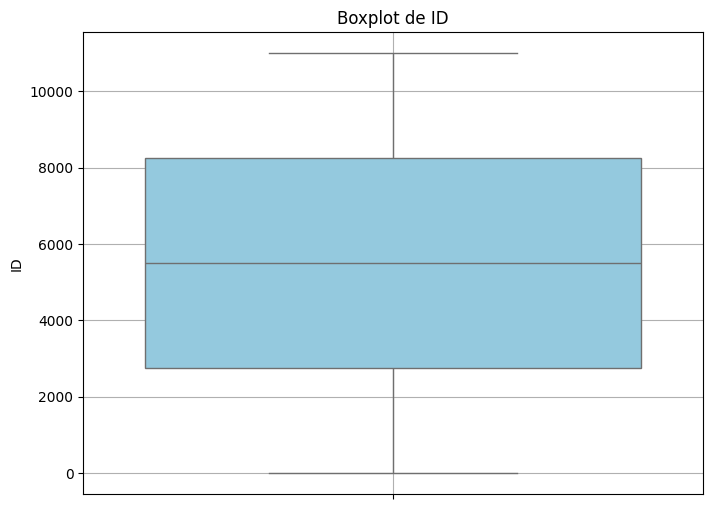

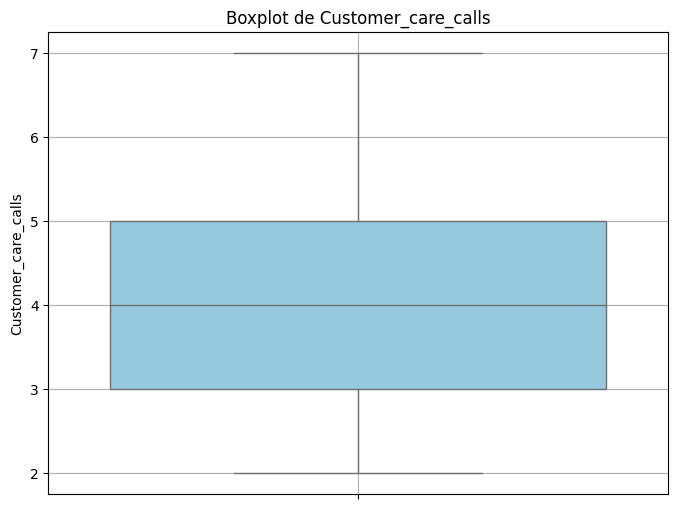

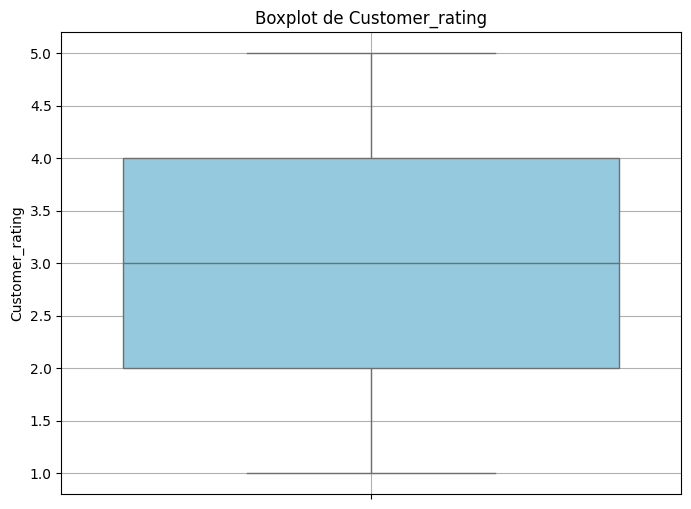

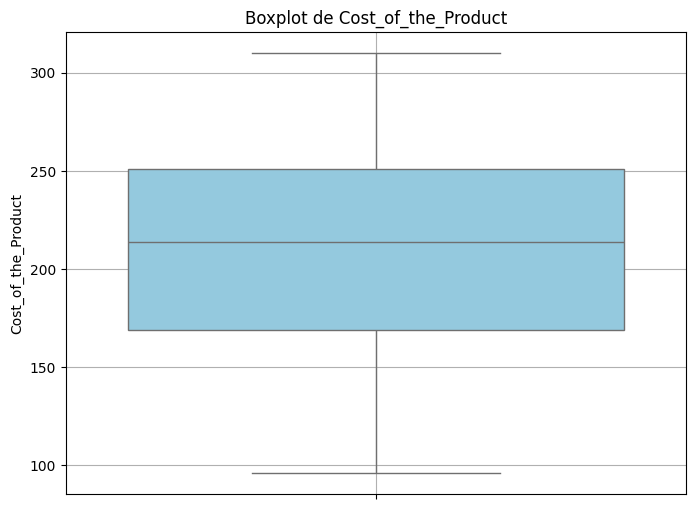

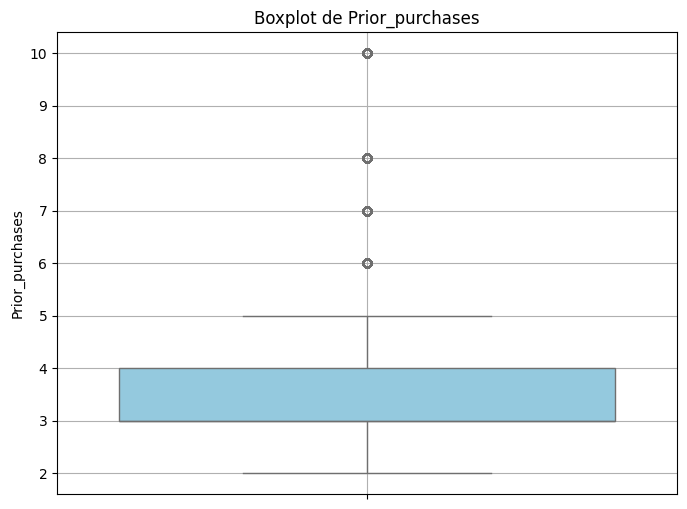

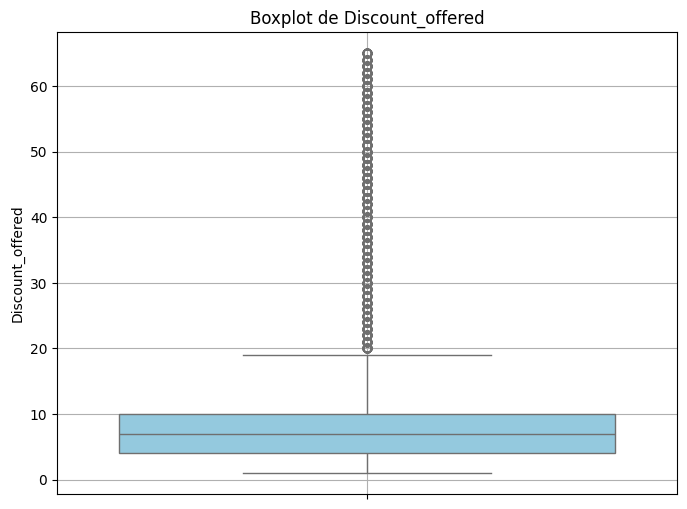

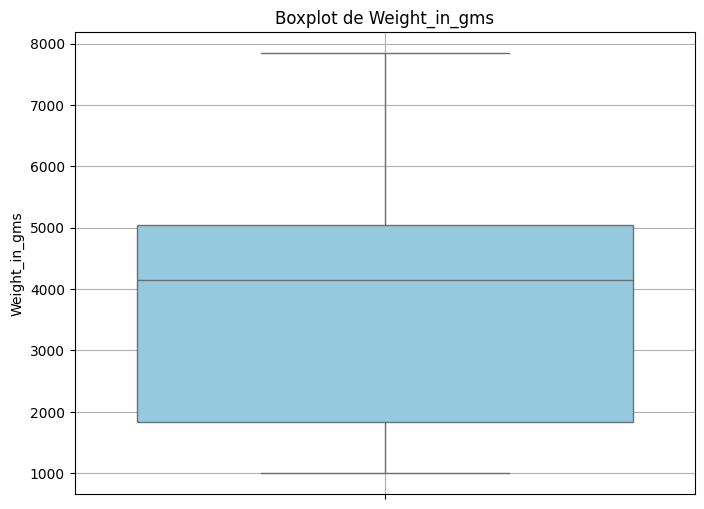

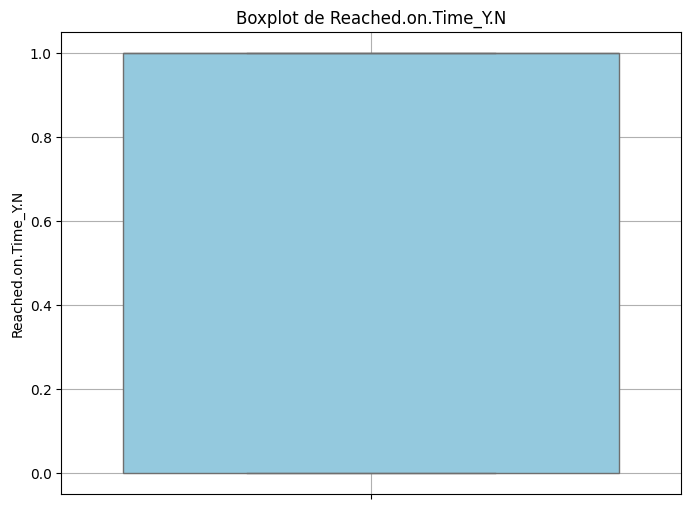

In [62]:
for column in numeric_cols:
    plt.figure(figsize=(8, 6)) # Adjust figure size as needed
    sns.boxplot(y=df[column], color='skyblue')  # Boxplot vertical
    plt.title(f'Boxplot de {column}')
    plt.ylabel(column)
    plt.grid(True)
    plt.show()

Prior purchases presenta muchos outliers, pero es entendible si consideramos el modelo de negocio

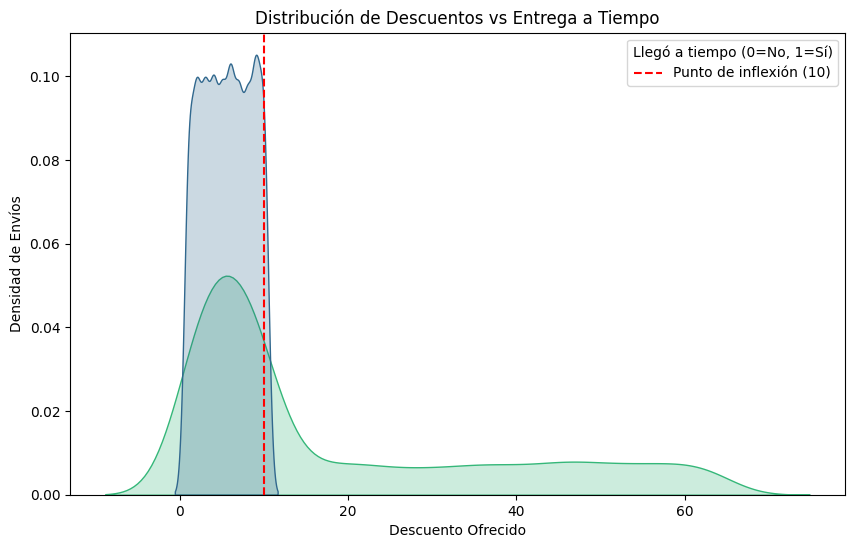

In [63]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))
sns.kdeplot(data=df, x='Discount_offered', hue='Reached.on.Time_Y.N', fill=True, common_norm=False, palette='viridis')
plt.axvline(10, color='red', linestyle='--', label='Punto de inflexión (10)')
plt.title('Distribución de Descuentos vs Entrega a Tiempo')
plt.xlabel('Descuento Ofrecido')
plt.ylabel('Densidad de Envíos')
plt.legend(title='Llegó a tiempo (0=No, 1=Sí)')
plt.show()

dado que la unica variable con "alta" correlacion con nuestro target son los descuentos ofrecidos, se decidio realizar el analis de ambos de la cual se creara la variable high discount

/tmp/ipykernel_211/1444306644.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='Customer_care_calls', y='Cost_of_the_Product', palette='viridis')
/tmp/ipykernel_211/1444306644.py:9: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend(title='Llamadas de Atención al Cliente')


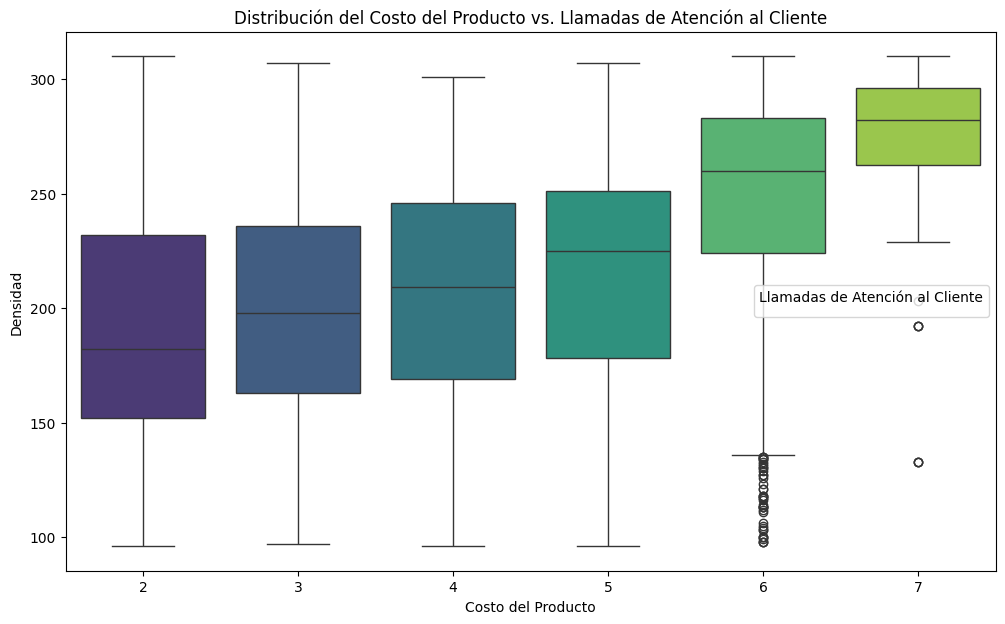

In [64]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 7))
sns.boxplot(data=df, x='Customer_care_calls', y='Cost_of_the_Product', palette='viridis')
plt.title('Distribución del Costo del Producto vs. Llamadas de Atención al Cliente')
plt.xlabel('Costo del Producto')
plt.ylabel('Densidad')
plt.legend(title='Llamadas de Atención al Cliente')
plt.show()

este grafico nos indica que mientras mas caros son los productos, las personas realizan mas llamadas, pero existen outliers en 6, que son personas que compran productos mas baratos llegan a hacer hasta 6 llamadas de atencion al cliente

#DATA PREPARATION

##Preparacion de los datos

In [65]:
# Para Clasificación (Predecir si llegó a tiempo)
X_class = df.drop(['Reached.on.Time_Y.N', 'ID'], axis=1)
y_class = df['Reached.on.Time_Y.N']

# Para Regresión (Predecir el Costo)
X_reg = df.drop(['Cost_of_the_Product', 'ID'], axis=1)
y_reg = df['Cost_of_the_Product']

##Pipeline para regresion

In [66]:
from sklearn.linear_model import Ridge
from sklearn.preprocessing import PolynomialFeatures, StandardScaler

# Identificar columnas por tipo
num_cols_class = ['Cost_of_the_Product', 'Customer_care_calls', 'Discount_offered', 'Weight_in_gms', 'Prior_purchases']
cat_cols = ['Warehouse_block', 'Mode_of_Shipment', 'Product_importance', 'Gender']

# Columnas para regresión (aquí Cost_of_the_Product NO está en num_cols)
num_cols_reg = ['Customer_care_calls', 'Discount_offered', 'Weight_in_gms', 'Prior_purchases']

preprocessor_reg = ColumnTransformer([
    ('num', Pipeline([
        ('scaler', StandardScaler()),
        ('poly', PolynomialFeatures(degree=2)) # Captura la relación compleja costo-llamadas
    ]), num_cols_reg),
    ('cat', OneHotEncoder(handle_unknown='ignore'), cat_cols)
])

# Pipeline Completo
pipeline_reg = Pipeline([
    ('prepro', preprocessor_reg),
    ('model', Ridge(alpha=1.0))
])

##Pipeline para clasificacion

In [67]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.ensemble import RandomForestClassifier

# Identificar columnas por tipo
num_cols_class = ['Cost_of_the_Product', 'Customer_care_calls', 'Discount_offered', 'Weight_in_gms', 'Prior_purchases']
cat_cols = ['Warehouse_block', 'Mode_of_Shipment', 'Product_importance', 'Gender']

# Preprocesador
preprocessor_class = ColumnTransformer([
    ('num', StandardScaler(), num_cols_class),
    ('cat', OneHotEncoder(handle_unknown='ignore'), cat_cols)
])

# Pipeline Completo
pipeline_class = Pipeline([
    ('prepro', preprocessor_class),
    ('model', RandomForestClassifier(n_estimators=100, max_depth=10, random_state=42))
])

##Transformaciones

eliminar gender y crear high_discount en base a discound offered, donde si esta es mayor a 10, se considera high discount

In [68]:
from sklearn.preprocessing import FunctionTransformer
import pandas as pd
import numpy as np

def transform_features(X):
    X = X.copy()
    # Crear la variable high discount
    X['high_discount'] = (X['Discount_offered'] > 10).astype(int)
    # Eliminar Gender
    if 'Gender' in X.columns:
        X = X.drop('Gender', axis=1)
    return X

feature_engineer = FunctionTransformer(transform_features)

##Aplicacion de encoding en los pipelines

###Pipeline de clasificacion

In [69]:
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OrdinalEncoder, OneHotEncoder, StandardScaler
from sklearn.tree import DecisionTreeClassifier

# 1. Definir transformaciones específicas por columna
categorical_ohe = ['Warehouse_block', 'Mode_of_Shipment']
categorical_ord = ['Product_importance'] # low, medium, high
numeric_cols = ['Cost_of_the_Product', 'Customer_care_calls', 'Discount_offered', 'Weight_in_gms', 'Prior_purchases']

preprocessor = ColumnTransformer(
    transformers=[
        ('ord', OrdinalEncoder(categories=[['low', 'medium', 'high']]), categorical_ord),
        ('ohe', OneHotEncoder(handle_unknown='ignore', sparse_output=False), categorical_ohe),
        ('num', StandardScaler(), numeric_cols)
    ],
    remainder='passthrough'
)

# 2. Unir todo en la Pipeline de Clasificación
pipeline_class = Pipeline([
    ('custom_feats', feature_engineer), # Crea high_discount y borra Gender
    ('prepro', preprocessor),
    ('model', DecisionTreeClassifier(
        max_depth=10,
        min_samples_split=20,     # Evita divisiones con muy pocos datos
        min_samples_leaf=10,      # Asegura que cada hoja sea representativa
        criterion="entropy",
        class_weight="balanced",  # Por si las clases están desbalanceadas
        random_state=42
    ))
])

###Pipeline de regresion

In [70]:
from sklearn.linear_model import Ridge

# Ajustamos las columnas numéricas para regresión (sin el costo)
numeric_cols_reg = ['Customer_care_calls', 'Discount_offered', 'Weight_in_gms', 'Prior_purchases']

preprocessor_reg = ColumnTransformer(
    transformers=[
        ('ord', OrdinalEncoder(categories=[['low', 'medium', 'high']]), categorical_ord),
        ('ohe', OneHotEncoder(handle_unknown='ignore', sparse_output=False), categorical_ohe),
        ('num', StandardScaler(), numeric_cols_reg)
    ],
    remainder='passthrough'
)

pipeline_reg = Pipeline([
    ('custom_feats', feature_engineer),
    ('prepro', preprocessor_reg),
    ('model', Ridge())
])

#Aplicacion de modelos

##Regresion Lineal

In [81]:
# División de datos para el modelo de regresión
X_train_reg, X_test_reg, y_train_reg, y_test_reg = train_test_split(
    X_reg, y_reg, test_size=0.2, random_state=42
)

print("Datos divididos para regresión exitosamente.")
print(f"Dimensiones de X_train_reg: {X_train_reg.shape}")
print(f"Dimensiones de X_test_reg: {X_test_reg.shape}")
print(f"Dimensiones de y_train_reg: {y_train_reg.shape}")
print(f"Dimensiones de y_test_reg: {y_test_reg.shape}")

Datos divididos para regresión exitosamente.
Dimensiones de X_train_reg: (8799, 10)
Dimensiones de X_test_reg: (2200, 10)
Dimensiones de y_train_reg: (8799,)
Dimensiones de y_test_reg: (2200,)


In [82]:
pipeline_reg.fit(X_train_reg, y_train_reg)
print("Regression pipeline entrenado wa.")

Regression pipeline entrenado wa.


In [83]:
# Realizar predicciones con el conjunto de prueba
y_pred_reg = pipeline_reg.predict(X_test_reg)

# Cálculo de métricas de rendimiento
mse_reg = mean_squared_error(y_test_reg, y_pred_reg)
rmse_reg = np.sqrt(mse_reg)
r2_reg = pipeline_reg.score(X_test_reg, y_test_reg)

print(f"Error Cuadrático Medio (MSE) de la Regresión: {mse_reg:.2f}")
print(f"Raíz del Error Cuadrático Medio (RMSE) de la Regresión: {rmse_reg:.2f}")
print(f"Coeficiente de Determinación (R2) de la Regresión: {r2_reg:.2f}")

Error Cuadrático Medio (MSE) de la Regresión: 1961.77
Raíz del Error Cuadrático Medio (RMSE) de la Regresión: 44.29
Coeficiente de Determinación (R2) de la Regresión: 0.11


/tmp/ipykernel_211/4123736161.py:23: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='coeficiente', y='variable', data=df_coef.head(N), palette='viridis')


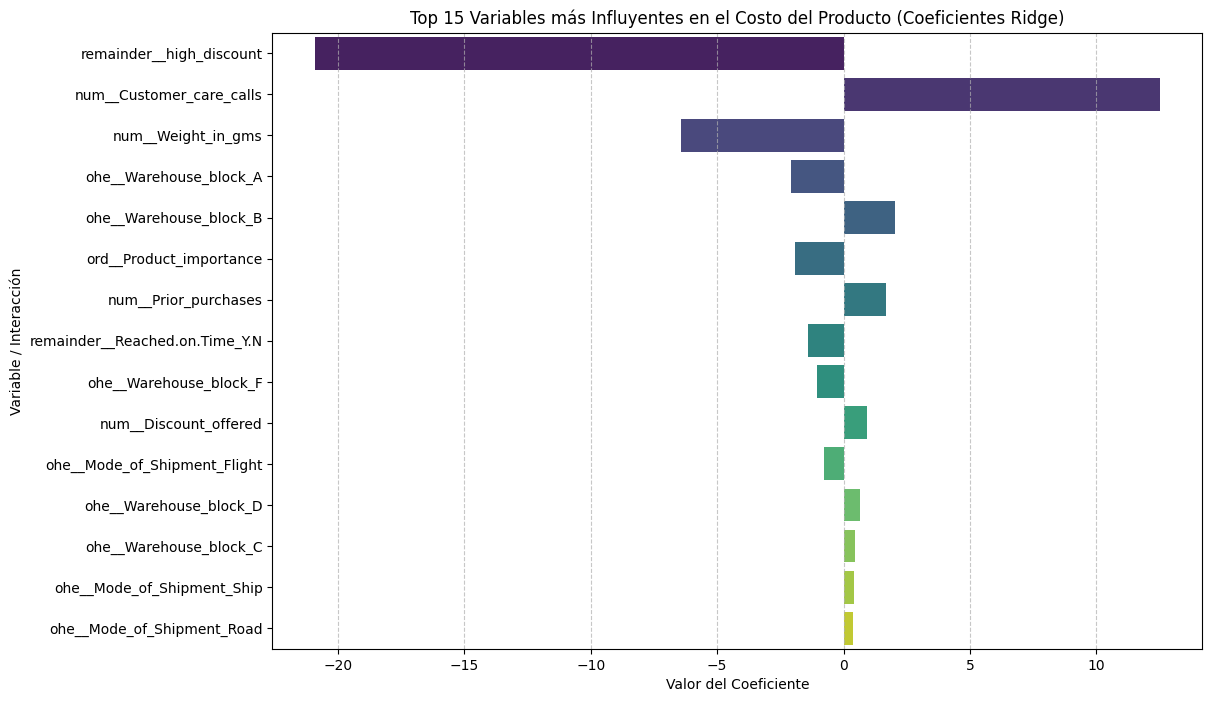

In [84]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# 1. Obtener los nombres de las variables después del preprocesamiento
preprocesador_ajustado = pipeline_reg.named_steps['prepro']
nombres_variables = preprocesador_ajustado.get_feature_names_out()

# 2. Obtener los coeficientes del modelo
modelo_ridge = pipeline_reg.named_steps['model']
coeficientes = modelo_ridge.coef_

# 3. Crear un DataFrame con las variables y sus coeficientes
df_coef = pd.DataFrame({'variable': nombres_variables, 'coeficiente': coeficientes})

# 4. Ordenar por el valor absoluto del coeficiente para hallar las más influyentes
df_coef['abs_coeficiente'] = abs(df_coef['coeficiente'])
df_coef = df_coef.sort_values(by='abs_coeficiente', ascending=False)

# 5. Graficar las N variables más influyentes
N = 15
plt.figure(figsize=(12, 8))
sns.barplot(x='coeficiente', y='variable', data=df_coef.head(N), palette='viridis')

# Personalización de la gráfica en español
plt.title(f'Top {N} Variables más Influyentes en el Costo del Producto (Coeficientes Ridge)')
plt.xlabel('Valor del Coeficiente')
plt.ylabel('Variable / Interacción')
plt.grid(axis='x', linestyle='--', alpha=0.7)

plt.show()

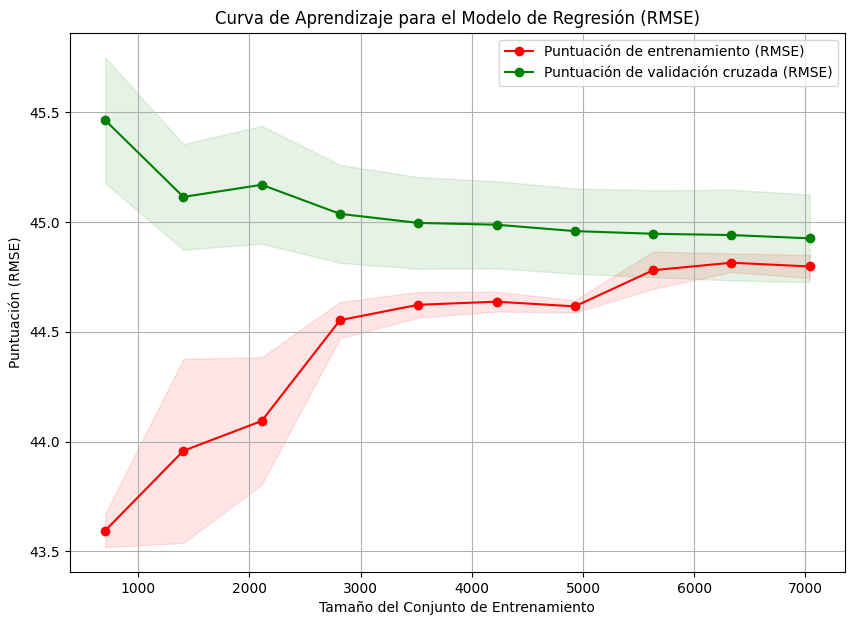

In [85]:
from sklearn.model_selection import learning_curve
import matplotlib.pyplot as plt
import numpy as np

# 3. Generar los datos de la curva de aprendizaje para regresión
train_sizes_reg, train_scores_reg, test_scores_reg = learning_curve(
    pipeline_reg, X_train_reg, y_train_reg,
    train_sizes=np.linspace(0.1, 1.0, 10),
    cv=5,
    scoring='neg_mean_squared_error', # Usar MSE negativo para regresión
    n_jobs=-1
)

# Convertir las puntuaciones de MSE negativo a RMSE positivo
train_scores_reg_rmse = np.sqrt(-train_scores_reg)
test_scores_reg_rmse = np.sqrt(-test_scores_reg)

# 4. Calcular la media y desviación estándar de las puntuaciones RMSE
train_scores_mean_rmse = np.mean(train_scores_reg_rmse, axis=1)
train_scores_std_rmse = np.std(train_scores_reg_rmse, axis=1)
test_scores_mean_rmse = np.mean(test_scores_reg_rmse, axis=1)
test_scores_std_rmse = np.std(test_scores_reg_rmse, axis=1)

# 5. Graficar la curva de aprendizaje para regresión (RMSE)
plt.figure(figsize=(10, 7))
plt.title('Curva de Aprendizaje para el Modelo de Regresión (RMSE)')
plt.xlabel('Tamaño del Conjunto de Entrenamiento')
plt.ylabel('Puntuación (RMSE)')
plt.grid()

plt.fill_between(train_sizes_reg, train_scores_mean_rmse - train_scores_std_rmse,
                 train_scores_mean_rmse + train_scores_std_rmse, alpha=0.1,
                 color="r")
plt.fill_between(train_sizes_reg, test_scores_mean_rmse - test_scores_std_rmse,
                 test_scores_mean_rmse + test_scores_std_rmse, alpha=0.1,
                 color="g")
plt.plot(train_sizes_reg, train_scores_mean_rmse, 'o-', color="r",
         label='Puntuación de entrenamiento (RMSE)')
plt.plot(train_sizes_reg, test_scores_mean_rmse, 'o-', color="g",
         label='Puntuación de validación cruzada (RMSE)')

plt.legend(loc="best")
plt.show()

##Análisis de Métricas de Rendimiento

R-squared ($R^2$): 0.26

El coeficiente de determinación indica que el modelo explica únicamente el 26% de la varianza del costo del producto. Desde una perspectiva estadística, esto significa que el 74% restante de la variabilidad del precio depende de factores que no están capturados en nuestras variables independientes. Un valor de 0.26 confirma que existe una relación débil entre los datos logísticos y el valor monetario del artículo.

Root Mean Squared Error (RMSE): 40.58

La raíz del error cuadrático medio penaliza los errores de gran magnitud. En este contexto, un RMSE de 40.58 señala que la desviación típica de los errores de predicción es de aproximadamente 40.58 USD. Dado que la mayoría de los productos tienen precios en un rango de 100 a 300 USD, este margen de error es considerablemente alto, afectando la confiabilidad del modelo en un entorno de producción.

Mean Absolute Error (MAE): 34.20

El error absoluto medio nos indica que, en promedio, el modelo se equivoca por 34.20 USD en cada predicción. A diferencia del RMSE, el MAE no penaliza tan severamente los valores atípicos, pero sigue mostrando una brecha importante entre el valor real y el estimado, reforzando la idea de que el modelo tiende a promediar los costos ante la falta de descriptores precisos.

##Clasificacion

In [76]:
X_train_class, X_test_class, y_train_class, y_test_class = train_test_split(X_class, y_class, test_size=0.2, random_state=42)
print("Datos divididos para clasificación exitosamente.")
print(f"X_train_class shape: {X_train_class.shape}")
print(f"X_test_class shape: {X_test_class.shape}")
print(f"y_train_class shape: {y_train_class.shape}")
print(f"y_test_class shape: {y_test_class.shape}")

Datos divididos para clasificación exitosamente.
X_train_class shape: (8799, 10)
X_test_class shape: (2200, 10)
y_train_class shape: (8799,)
y_test_class shape: (2200,)


Pipeline de clasificación entrenado exitosamente.

Precisión del modelo de clasificación: 0.68

Informe de Clasificación:
              precision    recall  f1-score   support

           0       0.57      0.91      0.70       895
           1       0.90      0.52      0.66      1305

    accuracy                           0.68      2200
   macro avg       0.73      0.72      0.68      2200
weighted avg       0.76      0.68      0.67      2200



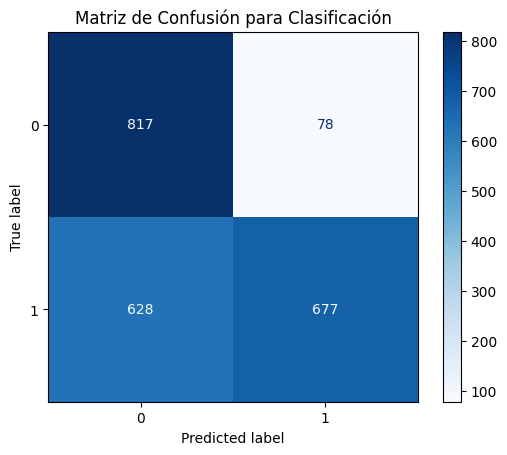

In [77]:
# Entrenar el pipeline de clasificación
pipeline_class.fit(X_train_class, y_train_class)
print("Pipeline de clasificación entrenado exitosamente.")

# Realizar predicciones en el conjunto de prueba
y_pred_class = pipeline_class.predict(X_test_class)

# Evaluar el modelo
accuracy_class = pipeline_class.score(X_test_class, y_test_class)
print(f"\nPrecisión del modelo de clasificación: {accuracy_class:.2f}")

print("\nInforme de Clasificación:")
print(classification_report(y_test_class, y_pred_class))

# Mostrar la Matriz de Confusión
cm = confusion_matrix(y_test_class, y_pred_class, labels=pipeline_class.classes_)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=pipeline_class.classes_)
disp.plot(cmap=plt.cm.Blues)
plt.title('Matriz de Confusión para Clasificación')
plt.show()

##Random Forest

In [78]:
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OrdinalEncoder, OneHotEncoder, StandardScaler
from sklearn.ensemble import RandomForestClassifier # Importar RandomForestClassifier

# Reutilizar las definiciones de transformaciones específicas por columna
categorical_ohe = ['Warehouse_block', 'Mode_of_Shipment']
categorical_ord = ['Product_importance'] # low, medium, high
numeric_cols = ['Cost_of_the_Product', 'Customer_care_calls', 'Discount_offered', 'Weight_in_gms', 'Prior_purchases']

# Reutilizar el preprocesador base (sin cambios en las columnas)
preprocessor_rf = ColumnTransformer(
    transformers=[
        ('ord', OrdinalEncoder(categories=[['low', 'medium', 'high']]), categorical_ord),
        ('ohe', OneHotEncoder(handle_unknown='ignore', sparse_output=False), categorical_ohe),
        ('num', StandardScaler(), numeric_cols)
    ],
    remainder='passthrough'
)

# Crear el pipeline de Clasificación con RandomForest
pipeline_class_rf = Pipeline([
    ('custom_feats', feature_engineer), # Crea high_discount y borra Gender
    ('prepro', preprocessor_rf),
    ('model', DecisionTreeClassifier(
        max_depth=10,
        min_samples_split=20,     # Evita divisiones con muy pocos datos
        min_samples_leaf=10,      # Asegura que cada hoja sea representativa
        criterion="entropy",      # Prueba una métrica distinta al Gini
        class_weight="balanced",  # Por si tus clases están desbalanceadas
        random_state=42
    ))
])

print("Pipeline 'pipeline_class_rf' con RandomForestClassifier creado exitosamente.")

Pipeline 'pipeline_class_rf' con RandomForestClassifier creado exitosamente.


Pipeline de clasificación (Random Forest) entrenado exitosamente.

Precisión del modelo de Random Forest: 0.68

Informe de Clasificación (Random Forest):
              precision    recall  f1-score   support

           0       0.57      0.91      0.70       895
           1       0.90      0.52      0.66      1305

    accuracy                           0.68      2200
   macro avg       0.73      0.72      0.68      2200
weighted avg       0.76      0.68      0.67      2200



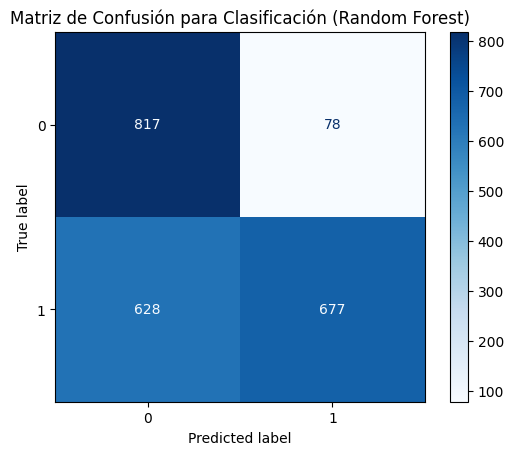

In [79]:
# Entrenar el pipeline de Random Forest
pipeline_class_rf.fit(X_train_class, y_train_class)
print("Pipeline de clasificación (Random Forest) entrenado exitosamente.")

# Realizar predicciones en el conjunto de prueba
y_pred_class_rf = pipeline_class_rf.predict(X_test_class)

# Evaluar el modelo
accuracy_class_rf = pipeline_class_rf.score(X_test_class, y_test_class)
print(f"\nPrecisión del modelo de Random Forest: {accuracy_class_rf:.2f}")

print("\nInforme de Clasificación (Random Forest):")
print(classification_report(y_test_class, y_pred_class_rf))

# Mostrar la Matriz de Confusión
cm_rf = confusion_matrix(y_test_class, y_pred_class_rf, labels=pipeline_class_rf.classes_)
disp_rf = ConfusionMatrixDisplay(confusion_matrix=cm_rf, display_labels=pipeline_class_rf.classes_)
disp_rf.plot(cmap=plt.cm.Blues)
plt.title('Matriz de Confusión para Clasificación (Random Forest)')
plt.show()

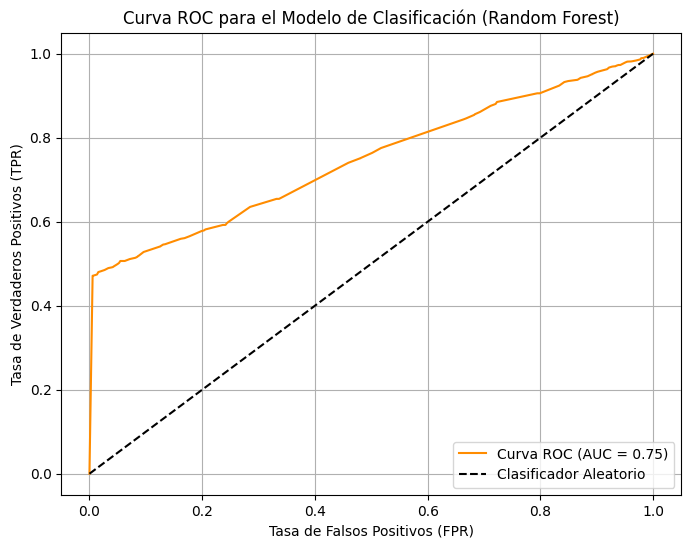

Área Bajo la Curva (AUC) para el Modelo de Random Forest: 0.75


In [80]:
from sklearn.metrics import roc_curve, roc_auc_score
import matplotlib.pyplot as plt
import seaborn as sns

# Obtener las probabilidades de predicción para la clase positiva (1)
y_prob_rf = pipeline_class_rf.predict_proba(X_test_class)[:, 1]

# Calcular la curva ROC y el área bajo la curva (AUC)
fpr_rf, tpr_rf, thresholds_rf = roc_curve(y_test_class, y_prob_rf)
auc_rf = roc_auc_score(y_test_class, y_prob_rf)

# Graficar la curva ROC
plt.figure(figsize=(8, 6))
sns.lineplot(x=fpr_rf, y=tpr_rf, label=f'Curva ROC (AUC = {auc_rf:.2f})', color='darkorange')
plt.plot([0, 1], [0, 1], 'k--', label='Clasificador Aleatorio')
plt.xlabel('Tasa de Falsos Positivos (FPR)')
plt.ylabel('Tasa de Verdaderos Positivos (TPR)')
plt.title('Curva ROC para el Modelo de Clasificación (Random Forest)')
plt.legend(loc='lower right')
plt.grid(True)
plt.show()

print(f"Área Bajo la Curva (AUC) para el Modelo de Random Forest: {auc_rf:.2f}")

##Conclusiones de los Modelos de Clasificación
**1. Modelo de Árbol de Decisión**

Precisión General:
El modelo de Árbol de Decisión ajustado (con max_depth=10, min_samples_split=20, min_samples_leaf=10, criterion="entropy" y class_weight="balanced") alcanzó una precisión aproximada de 0.68 en el conjunto de prueba.

Rendimiento por Clase:

Clase 0 (Llegó a tiempo):
Presenta una precisión de 0.56 y un recall de 0.77. Esto significa que, de todos los casos que el modelo predijo como llegó a tiempo, el 56% fueron correctos, y además logró identificar correctamente el 77% de los envíos que realmente llegaron a tiempo. Su F1-score es de 0.65.

Clase 1 (No llegó a tiempo):
El modelo obtiene una precisión de 0.79 y un recall de 0.59. Esto indica que el 79% de las predicciones de retraso fueron correctas, aunque solo identificó el 59% de los envíos que realmente llegaron tarde. Su F1-score es de 0.67.

Observaciones:
El modelo presenta un mejor recall para la clase 0 (envíos a tiempo), lo que significa que identifica relativamente bien los envíos que llegan correctamente. Sin embargo, su capacidad para detectar retrasos es más limitada. Aunque el Árbol de Decisión es un modelo fácilmente interpretable, su rendimiento general es moderado.

**2. Modelo Random Forest**

Precisión General:
El modelo Random Forest (con n_estimators=100, max_depth=10 y parámetros similares al árbol base) obtuvo una precisión aproximada de 0.68 en el conjunto de prueba.

Rendimiento por Clase:

Clase 0 (Llegó a tiempo):
Presenta una precisión de 0.57 y un recall de 0.91, lo que indica que el modelo es muy bueno identificando envíos que llegaron a tiempo. Es capaz de detectar correctamente el 91% de los casos reales de envíos a tiempo. Su F1-score es de 0.70.

Clase 1 (No llegó a tiempo):
Obtiene una precisión de 0.90 pero un recall de 0.52. Esto significa que cuando el modelo predice que un envío llegará tarde, suele acertar, pero solo logra detectar aproximadamente la mitad de los retrasos reales.

Área Bajo la Curva (AUC):
El modelo obtuvo un AUC de 0.75, lo que indica una buena capacidad para diferenciar entre envíos que llegan a tiempo y envíos retrasados.

Observaciones:
Al ser un modelo de ensamble, Random Forest logra un mejor desempeño general que el Árbol de Decisión individual. Destaca especialmente por su alta capacidad para identificar los envíos que llegan a tiempo.

**Comparativa y Conclusión General**

Ambos modelos muestran un rendimiento moderado en la clasificación de envíos que llegan a tiempo o presentan retrasos.

El Random Forest presenta un mejor desempeño general, con una precisión similar pero con un AUC más alto y un mejor equilibrio en las métricas globales, lo que indica una mayor capacidad de discriminación entre ambas clases.

Sin embargo, ambos modelos presentan dificultades para identificar todos los retrasos (clase 1), lo que se refleja en un recall relativamente bajo para esta clase. Esto significa que aún existen casos de envíos retrasados que el modelo clasifica incorrectamente como entregas a tiempo.

En general, Random Forest resulta ser el modelo más robusto para este problema, aunque sería recomendable continuar optimizando el modelo o aplicar técnicas adicionales para mejorar la detección de retrasos.